# Workshop Notebook 1: Building an End-to-End ML Pipeline for Streamflow Prediction

**CIROH Developer's Conference 2026 | Foundations of Machine Learning**

---

## Goals

Build complete machine learning pipeline that predicts **daily streamflow** at 10 USGS-gauged basins in the southeastern United States, driven by daily climate forcings from the [CAMELS dataset](https://ral.ucar.edu/solutions/products/camels).

## Workflow

| # | Step | Key concepts |
|---|------|-------------|
| 1 | Explore the data | CAMELS forcings, streamflow, basin attributes |
| 2 | Preprocess | Temporal splits, normalization, log-transform, sliding-window sequences |
| 3 | Build the model | `nn.Module`, LSTM architecture, encoder → LSTM → decoder, trainable parameters |
| 4 | Train | Loss function, optimizer, backpropagation, gradient clipping, learning curves |
| 5 | Evaluate | Nash-Sutcliffe Efficiency (NSE), hydrograph plots, observed-vs-predicted scatter plots |
| 6 | Tune & Diagnose | Hyperparameter tuning, overfitting, underfitting, model capacity |
| 7 | Engineer features | Temporal features, seasonal encoding, input representation, baseline vs. feature-engineered comparison |

## The prediction task

Given a **365-day sequence** of daily meteorological variables, predict the streamflow at each of those 365 days...

```
Input x: (365 days) × [prcp, tmean, pet, dayl, srad, vp]
Output y: (365 days) × streamflow  (ft3/s)
```

<!-- This is a **sequence-to-sequence regression** problem — natural fit for LSTM. -->


In [ ]:
# Preliminaries -- imports, device setup, and workshop flags.

import sys
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cpu")  # CPU-only for this workshop
print(f"Using device: {device}")

ROOT = Path("..").resolve()
DATA_DIR = ROOT / "data"
sys.path.insert(0, str(ROOT))

print(f"PyTorch version: {torch.__version__}")

# ------------------------------------------------------------------------------
# Workshop flags
# ------------------------------------------------------------------------------
# (1) TRAIN_FROM_SCRATCH = False to load pre-trained weights instead of
#   training — useful during the workshop to save time.
# (2) SAVE_WEIGHTS = True to save model weights after training so they can be
#   reused later.

TRAIN_FROM_SCRATCH = False  # False = load pre-saved weights
SAVE_WEIGHTS       = False  # True = save weights after each training run

WEIGHTS_DIR = ROOT / "weights"
if SAVE_WEIGHTS:
    WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------------------------

from utils import (
    StreamflowDataset,
    count_params,
    nse_score,
    train_model,
    predict_full_timeseries,
    make_overfit_loader,
    make_feature_engineered_inputs,
    evaluate_streamflow_model,
    load_or_train,
)

from plots import (
    plot_gage_locations,
    plot_basin_overview,
    plot_target_normalization_histogram,
    plot_learning_curves,
    plot_hydrograph,
    plot_scatter_basins,
    plot_bias_variance,
    plot_feature_engineering_comparison,
    plot_nse_comparison,
)

---
## 1. Exploring the CAMELS Dataset

The **CAMELS** (Catchment Attributes and Meteorology for Large-sample Studies) dataset provides long-record hydrometeorological time series for hundreds of US watersheds. We work with a curated **10-basin subset** from the southeastern US.

**Data dimensions:**
- **12,418 daily timesteps** — 1980-10-01 through 2014-09-30
- **6 forcing variables** - climate inputs that drive streamflow
- **1 target variable** — observed streamflow (ft³/s)
- **35 static basin attributes** — physical and geologic characteristics

| Forcing variable | Description |
|-----------------|-------------|
| `prcp`  | Precipitation (mm/day) |
| `tmean` | Mean air temperature (°C) |
| `pet`   | Potential evapotranspiration (mm/day) |
| `dayl`  | Day length (seconds) |
| `srad`  | Solar radiation (W/m²) |
| `vp`    | Vapor pressure (Pa) |


In [2]:
from camels_loader import CamelsSubsetLoader, FORCING_NAMES, ATTRIBUTE_NAMES

loader = CamelsSubsetLoader(
    pickle_path=str(DATA_DIR / "camels_daymetv2_subset"),
    gage_id_path=str(DATA_DIR / "gage_id_subset.npy"),
)

print(loader)
print(f"\nForcing variables ({len(FORCING_NAMES)}): {FORCING_NAMES}")
print(f"Static attributes ({len(ATTRIBUTE_NAMES)}): {ATTRIBUTE_NAMES[:5]} ... (first 5 of {len(ATTRIBUTE_NAMES)})")
print(f"\nForcings array shape: {loader.forcings.shape} (time, basins, vars)")
print(f"Target array shape: {loader.target.shape} (time, basins, 1)")
print(f"Attributes shape: {loader.attributes.shape} (basins, attrs)")


CamelsSubsetLoader(basins=10, timesteps=12418, dates=1980-10-01 to 2014-09-30)

Forcing variables (6): ['prcp', 'tmean', 'pet', 'dayl', 'srad', 'vp']
Static attributes (35): ['p_mean', 'pet_mean', 'p_seasonality', 'frac_snow', 'aridity'] ... (first 5 of 35)

Forcings array shape: (12418, 10, 6) (time, basins, vars)
Target array shape: (12418, 10, 1) (time, basins, 1)
Attributes shape: (10, 35) (basins, attrs)


In [3]:
# Basin summary table
df_meta = pd.DataFrame({
    "Gage ID": loader.gage_ids,
    "Mean Q (ft³/s)": np.nanmean(loader.target[:, :, 0], axis=0).round(1),
    "Mean Precip (mm/d)": loader.forcings[:, :, FORCING_NAMES.index("prcp")].mean(0).round(2),
    "Basin Area (km²)": loader.attributes[:, ATTRIBUTE_NAMES.index("area_gages2")].round(0).astype(int),
    "Forest Cover (%)": (loader.attributes[:, ATTRIBUTE_NAMES.index("frac_forest")] * 100).round(1),
    "Mean Elevation (m)": loader.attributes[:, ATTRIBUTE_NAMES.index("elev_mean")].round(0).astype(int),
}).set_index("Gage ID")

df_meta


,Mean Q (ft³/s),Mean Precip (mm/d),Basin Area (km²),Forest Cover (%),Mean Elevation (m)
Gage ID,,,,,
2111180,89.699997,3.66,131,100.000000,551
2111500,131.000000,3.56,234,98.300003,454
2112120,176.500000,3.55,322,90.099998,460
2112360,121.000000,3.44,205,88.199997,406
2118500,186.600006,3.53,401,70.599998,337
2140991,359.399994,3.67,522,98.199997,529
3161000,418.399994,3.99,528,99.599998,834
3471500,108.099998,3.36,198,82.199997,1024
3473000,468.000000,3.44,785,86.300003,916


In [ ]:
# Map of the 10 watershed boundaries in the southern Appalachians.
# After evaluating the model (Section 5), you can pass nse_by_basin=nse_baseline
# to color each watershed by its NSE score.

plot_gage_locations(loader, DATA_DIR)

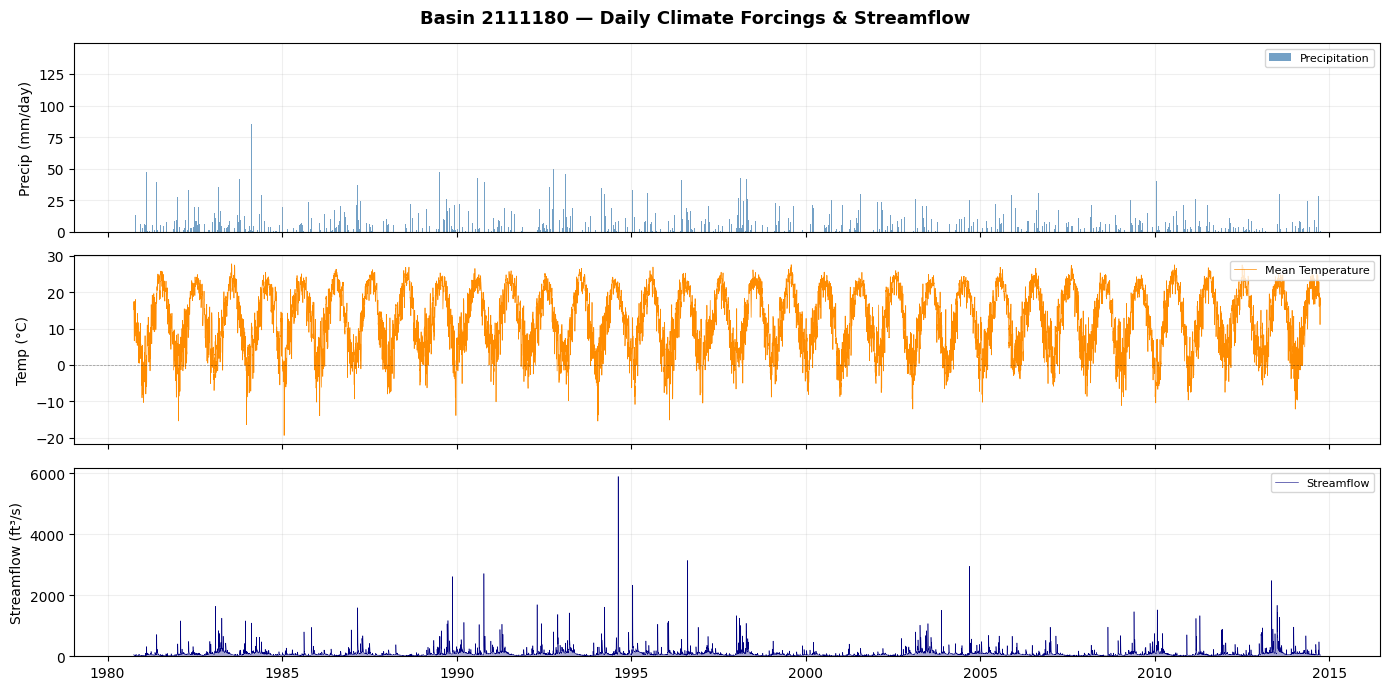

In [4]:
# YOUR TURN — change basin_idx (0–9) to explore different basins.
plot_basin_overview(loader, basin_idx=0)

**Key observations to discuss:**
- Streamflow lags behind precipitation — water takes time to travel through the watershed
- Seasonal patterns in temperature drive snowmelt and evapotranspiration signals
- There are gaps (NaN) in the streamflow record — we'll handle these in preprocessing



---
## 2. Data Preprocessing

Raw data must be transformed before it can be fed into a neural network.

| Step | Why it matters |
|------|---------------|
| **Temporal split** | Evaluate on unseen future data — never shuffle a time series |
| **Normalization** | Stable gradients; computed from training data *only* to prevent leakage |
| **Log-transform target** | Streamflow is right-skewed; log-space improves learning of low flows |
| **Sequence construction** | LSTMs operate on windows of past observations |

### Data leakage

Computing normalization statistics on the full dataset (including val/test) is a common mistake — the model indirectly "sees" future data. Always fit scalers on **training data only**, then apply the same statistics to val/test.


In [5]:
# 2.1: Temporal train / val / test split

TRAIN_END = "1999-09-30" # ~19 years of training
VAL_END = "2008-09-30" # ~9 years of validation
# Test period: 2008-10-01 -> 2014-09-30 (~6 years)

dates_idx = pd.DatetimeIndex(loader.dates)
train_mask = dates_idx <= pd.Timestamp(TRAIN_END)
val_mask = (dates_idx > pd.Timestamp(TRAIN_END)) & (dates_idx <= pd.Timestamp(VAL_END))
test_mask = dates_idx > pd.Timestamp(VAL_END)

x_train = loader.forcings[train_mask]
x_val = loader.forcings[val_mask]
x_test = loader.forcings[test_mask]

y_train = loader.target[train_mask]
y_val = loader.target[val_mask]
y_test = loader.target[test_mask]

dates_train = loader.dates[train_mask]
dates_val = loader.dates[val_mask]
dates_test = loader.dates[test_mask]

print(f"Train: {dates_train[0].date()} -> {dates_train[-1].date()}  ({train_mask.sum():,} days)")
print(f"Val:   {dates_val[0].date()} -> {dates_val[-1].date()}    ({val_mask.sum():,} days)")
print(f"Test:  {dates_test[0].date()} -> {dates_test[-1].date()}    ({test_mask.sum():,} days)")


Train: 1980-10-01 -> 1999-09-30  (6,939 days)
Val:   1999-10-01 -> 2008-09-30    (3,288 days)
Test:  2008-10-01 -> 2014-09-30    (2,191 days)


In [6]:
# 2.2: Normalize forcing variables (z-score)
# Mean and std are computed from TRAINING DATA ONLY.

x_mean = x_train.mean(axis=(0, 1), keepdims=True)  # (1, 1, 6)
x_std = x_train.std(axis=(0, 1), keepdims=True) + 1e-8

x_train_norm = (x_train - x_mean) / x_std
x_val_norm = (x_val - x_mean) / x_std
x_test_norm = (x_test - x_mean) / x_std

print("Normalization statistics (training set only):")
for i, name in enumerate(FORCING_NAMES):
    print(f"  {name}: mean={x_mean[0,0,i]:.3f}, std={x_std[0,0,i]:.3f}")


Normalization statistics (training set only):
  prcp: mean=3.608, std=8.095
  tmean: mean=11.853, std=8.530
  pet: mean=3.117, std=1.704
  dayl: mean=43193.746, std=6195.814
  srad: mean=343.673, std=113.159
  vp: mean=1039.059, std=562.605


NaN values in training target: 1,674  (will be masked during loss computation)


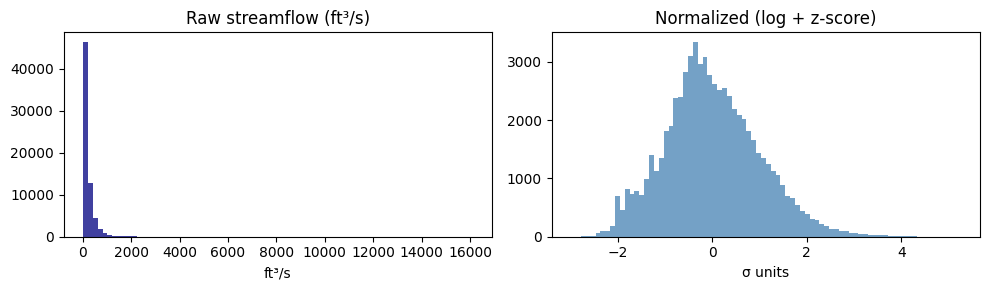

In [7]:
# 2.3: Normalize streamflow (log1p + z-score)
# Streamflow is heavily right-skewed — log1p compresses rare flood events
# and prevents the model from focusing only on peak flows.

y_train_log = np.log1p(np.clip(y_train, 0, None))
y_log_mean = float(np.nanmean(y_train_log))
y_log_std = float(np.nanstd(y_train_log[~np.isnan(y_train_log)])) + 1e-8


def normalize_target(y: np.ndarray) -> np.ndarray:
    return (np.log1p(np.clip(y, 0, None)) - y_log_mean) / y_log_std


def denormalize_target(y_norm: np.ndarray) -> np.ndarray:
    return np.expm1(y_norm * y_log_std + y_log_mean)


y_train_norm = normalize_target(y_train)
y_val_norm = normalize_target(y_val)
y_test_norm = normalize_target(y_test)

print(f"NaN values in training target: {np.isnan(y_train).sum():,}  (will be masked during loss computation)")

# The histogram is a visual check; the plotting details live in plots.py.
plot_target_normalization_histogram(y_train, y_train_norm)


In [8]:
# 2.4: Sliding-window Dataset
# StreamflowDataset is imported from utils.py.
# Conceptually: each sample is a moving window of 365 days of forcings and streamflow.
# __getitem__ returns one (x_window, y_window) pair; DataLoader batches many windows.

SEQ_LEN = 365  # 1-year context window
STRIDE = 7     # weekly stride balances data coverage and training speed

train_ds = StreamflowDataset(x_train_norm, y_train_norm, seq_len=SEQ_LEN, stride=STRIDE)
val_ds = StreamflowDataset(x_val_norm, y_val_norm, seq_len=SEQ_LEN, stride=STRIDE)

print(f"Training samples: {len(train_ds):,}")
print(f"Validation samples: {len(val_ds):,}")
print(f"Sample shapes — x: {train_ds[0][0].shape}, y: {train_ds[0][1].shape}")


Training samples: 9,400
Validation samples: 4,180
Sample shapes — x: torch.Size([365, 6]), y: torch.Size([365])


In [9]:
# 2.5: DataLoaders

BATCH_SIZE = 128

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

x_b, y_b = next(iter(train_loader))
print(f"Mini-batch shapes:")
print(f"  x: {tuple(x_b.shape)} (batch, seq_len, features)")
print(f"  y: {tuple(y_b.shape)} (batch, seq_len)")
print(f"\nAny NaN in x? {torch.isnan(x_b).any().item()}")
print(f"Any NaN in y? {torch.isnan(y_b).any().item()}  <- NaNs in targets are expected")


Mini-batch shapes:
  x: (128, 365, 6) (batch, seq_len, features)
  y: (128, 365) (batch, seq_len)

Any NaN in x? False
Any NaN in y? True  <- NaNs in targets are expected



---
## 3. The LSTM Model

### Why an LSTM?

Streamflow prediction is a classic **long-range dependency** problem. Today's streamflow can depend on precipitation from *months* ago (e.g., snowpack). Standard RNNs suffer from **vanishing gradients** and cannot learn these dependencies.

An **LSTM** adds three *gates* that regulate how information flows through time:

```
  Forget gate : decides what to erase from the cell state (long-term memory)
  Input gate : decides what new information to write into the cell state
  Output gate : decides what part of the cell state to expose as hidden state
```

### Architecture

```
x  (batch, seq_len, 6)
 │
 ▼  Linear encoder  ->  ReLU
   (batch, seq_len, hidden_size)
 │
 ▼  LSTM  (hidden_size -> hidden_size)
   (batch, seq_len, hidden_size)
 │
 ▼  Dropout
 │
 ▼  Linear decoder
   (batch, seq_len, 1)  ->  squeeze  ->  (batch, seq_len)
```

The key **capacity hyperparameter** is `hidden_size`. A larger value gives the model more "working memory" at the cost of more parameters and a higher risk of overfitting.


In [10]:
class LstmModel(nn.Module):
    """LSTM for sequence-to-sequence streamflow prediction.

    Parameters
    ----------
    n_features : number of input forcing variables
    hidden_size : number of LSTM hidden units (controls model capacity)
    n_layers : number of stacked LSTM layers (controls depth)
    dropout : dropout probability (0 = no regularization)
    """

    def __init__(self, n_features: int, hidden_size: int = 64,
                 n_layers: int = 1, dropout: float = 0.0):
        super().__init__()
        self.hidden_size = hidden_size
        self.n_layers = n_layers

        self.input_proj = nn.Linear(n_features, hidden_size)
        self.lstm = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=n_layers,
            dropout=dropout if n_layers > 1 else 0.0,
            batch_first=True,
        )
        self.dropout = nn.Dropout(dropout)
        self.output_proj = nn.Linear(hidden_size, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Parameters
        ----------
        x : (batch, seq_len, n_features)

        Returns
        -------
        (batch, seq_len)
        """
        x = torch.relu(self.input_proj(x))
        lstm_out, _ = self.lstm(x)
        out = self.output_proj(self.dropout(lstm_out))
        return out.squeeze(-1)

LstmModel(
  (input_proj): Linear(in_features=6, out_features=64, bias=True)
  (lstm): LSTM(64, 64, batch_first=True)
  (dropout): Dropout(p=0.4, inplace=False)
  (output_proj): Linear(in_features=64, out_features=1, bias=True)
)

Trainable parameters: 33,793

Forward pass: (8, 365, 6) → (8, 365)  ✓


In [ ]:
# YOUR TURN — change hidden_size (try 8, 32, 128, 256) and re-run this cell.
# Watch how the parameter count and model printout change.

N_FEATURES = len(FORCING_NAMES)  # 6
model = LstmModel(n_features=N_FEATURES, hidden_size=64, n_layers=1, dropout=0.4).to(device)

print(model)
print(f"\nTrainable parameters: {count_params(model):,}")

x_dummy = torch.randn(8, SEQ_LEN, N_FEATURES).to(device)
with torch.no_grad():
    out_dummy = model(x_dummy)
print(f"\nForward pass: {tuple(x_dummy.shape)} → {tuple(out_dummy.shape)}  ✓")

> **Exercise** — In the cell above, change `hidden_size` to `8`, `32`, and `256`.
> How does the parameter count scale? *(Hint: roughly `4 × hidden_size²` due to the LSTM weight matrices.)*
>
> **Exercise** — Set `n_layers=2`. What new line appears in the model printout?
>
> **Reset** — Before moving on, set `hidden_size=64`, `n_layers=1`, `dropout=0.4` — these are the baseline settings used in Section 4.


---
## 4. Training the Model

Training iterates over the data in mini-batches:

1. **Forward pass** — input sequences -> predicted streamflow
2. **Loss** — measure prediction error on non-missing timesteps
3. **Backward pass** — `loss.backward()` computes gradients for every parameter
4. **Optimizer step** — nudge weights in the direction that reduces loss

We use **Adam** (adaptive learning rates per parameter) and a **learning-rate scheduler** that halves the LR when validation loss plateaus.

### Loss function

We minimize **MSE in normalized log-space**. NaN positions (missing observations) are masked out so they do not contribute to the gradient.

### Nash-Sutcliffe Efficiency (NSE)

$$\text{NSE} = 1 - \frac{\sum_t (Q_t^\text{obs} - Q_t^\text{sim})^2}
                           {\sum_t (Q_t^\text{obs} - \bar{Q}^\text{obs})^2}$$

| NSE | Meaning |
|-----|---------|
| 1.0 | Perfect prediction |
| 0.0 | No better than predicting the long-term mean every day |
| < 0 | Worse than the mean |

NSE > 0.6 is generally acceptable; NSE > 0.8 is excellent for daily streamflow.


In [11]:
def masked_mse_loss(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    """MSE loss that ignores NaN positions in the target."""
    mask = ~torch.isnan(target)
    if mask.sum() == 0:
        return pred.sum() * 0.0
    return ((pred[mask] - target[mask]) ** 2).mean()


# nse_score is imported from utils — see the NSE formula in the markdown above

In [12]:
# The core training loop — every PyTorch training script follows this pattern:
#
#   for epoch in range(n_epochs):
#       for x_batch, y_batch in train_loader:
#           optimizer.zero_grad()              # clear old gradients
#           predictions = model(x_batch)       # forward pass
#           loss = loss_fn(predictions, y_batch) # compute error
#           loss.backward()                    # backprop: compute gradients
#           optimizer.step()                   # update weights
#
# The full version in utils.py wraps this with:
#   - Adam optimizer + ReduceLROnPlateau scheduler
#   - Gradient clipping (prevents exploding gradients in LSTMs)
#   - Best-weight checkpointing (restores lowest val-loss weights)
#
# train_model is already imported at the top of this notebook.
# Open utils.py to read the full implementation.


In [13]:
model = LstmModel(n_features=N_FEATURES, hidden_size=64, n_layers=1, dropout=0.4).to(device)
print(f"Baseline model — {count_params(model):,} trainable parameters")

train_losses, val_losses = load_or_train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    n_epochs=30,
    weights_path=WEIGHTS_DIR / "baseline.pt",
    train_from_scratch=TRAIN_FROM_SCRATCH,
    save_weights=SAVE_WEIGHTS,
)

print(f"\nBest val loss: {min(val_losses):.4f}")


Baseline model — 33,793 trainable parameters
Loaded weights from baseline.pt  (best val loss: 0.5229)

Best val loss: 0.5229


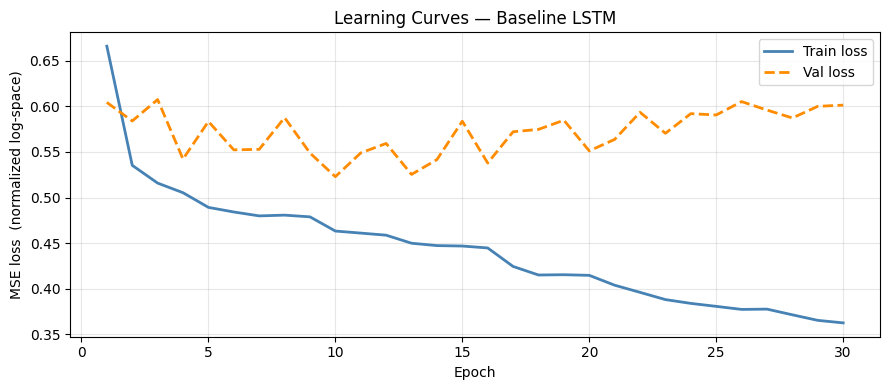

In [14]:
plot_learning_curves(train_losses, val_losses, title="Learning Curves — Baseline LSTM")

# What to look for:
# ✓  Both curves decrease and level off -> healthy training
# ✗  Val curve rises while train falls -> overfitting
# ✗  Both curves stay high and flat -> underfitting



---
## 5. Evaluating the Model

After training, we assess performance on the **held-out test period (2008–2014)**.

For a fair evaluation:
- Use the same normalization statistics computed on the training set
- Denormalize predictions back to ft^3/s before computing NSE
- Inspect both aggregate metrics *and* individual hydrographs


In [15]:
# predict_full_timeseries is imported from utils.
# It runs sliding-window inference: for each day t, feed x[t-seq_len:t]
# into the model and record the last output step as the prediction for day t.

pred_norm_test = predict_full_timeseries(model, x_test_norm, seq_len=SEQ_LEN)
pred_cfs_test = denormalize_target(pred_norm_test)
obs_cfs_test = loader.target[test_mask, :, 0]

print("NSE per basin — test period (2008–2014):")
nse_baseline = {}
for i, gid in enumerate(loader.gage_ids):
    nse = nse_score(pred_cfs_test[:, i], obs_cfs_test[:, i])
    nse_baseline[gid] = nse
    print(f"  Basin {gid}: NSE = {nse:.3f}")

print(f"\n  Median NSE: {np.nanmedian(list(nse_baseline.values())):.3f}")
print(f"  Mean NSE:   {np.nanmean(list(nse_baseline.values())):.3f}")


NSE per basin — test period (2008–2014):
  Basin 2111180: NSE = -0.659
  Basin 2111500: NSE = -0.051
  Basin 2112120: NSE = 0.129
  Basin 2112360: NSE = -0.187
  Basin 2118500: NSE = 0.097
  Basin 2140991: NSE = 0.118
  Basin 3161000: NSE = 0.240
  Basin 3471500: NSE = -0.636
  Basin 3473000: NSE = 0.058
  Basin 3479000: NSE = 0.092

  Median NSE: 0.075
  Mean NSE:   -0.080


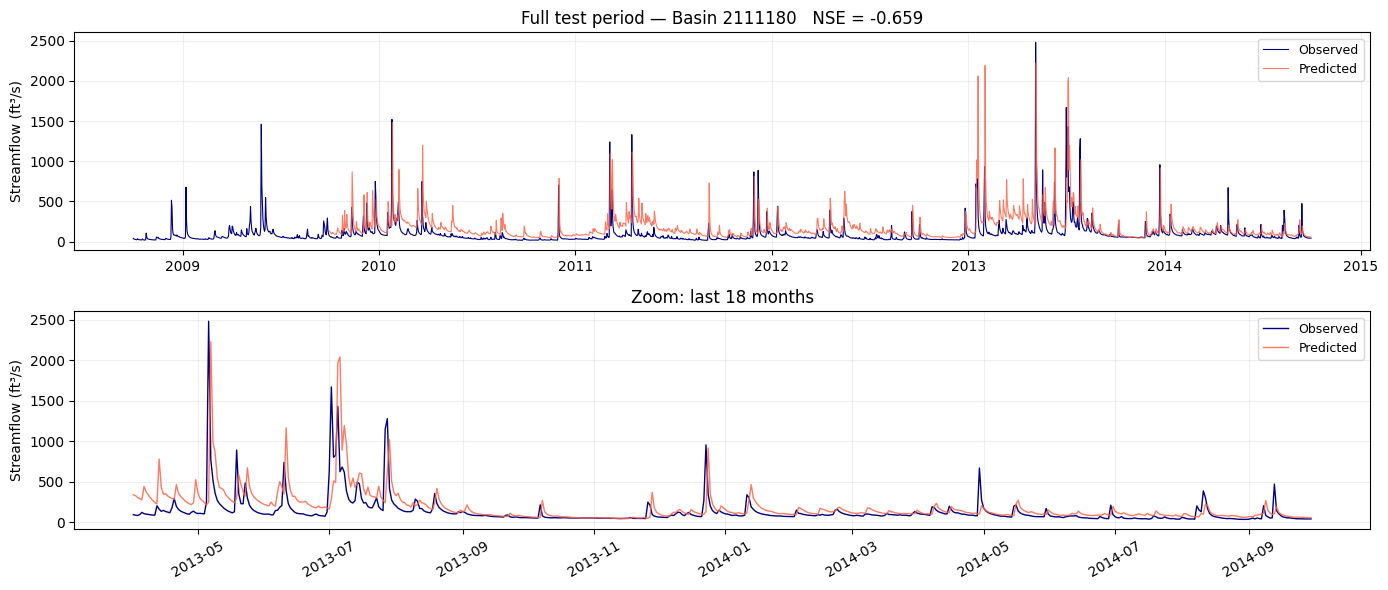

In [16]:
# YOUR TURN — change basin_idx (0–9) to see the hydrograph for different basins.
plot_hydrograph(
    dates_test=dates_test,
    obs_cfs_test=obs_cfs_test,
    pred_cfs_test=pred_cfs_test,
    gage_ids=loader.gage_ids,
    nse_by_basin=nse_baseline,
    basin_idx=0,
)

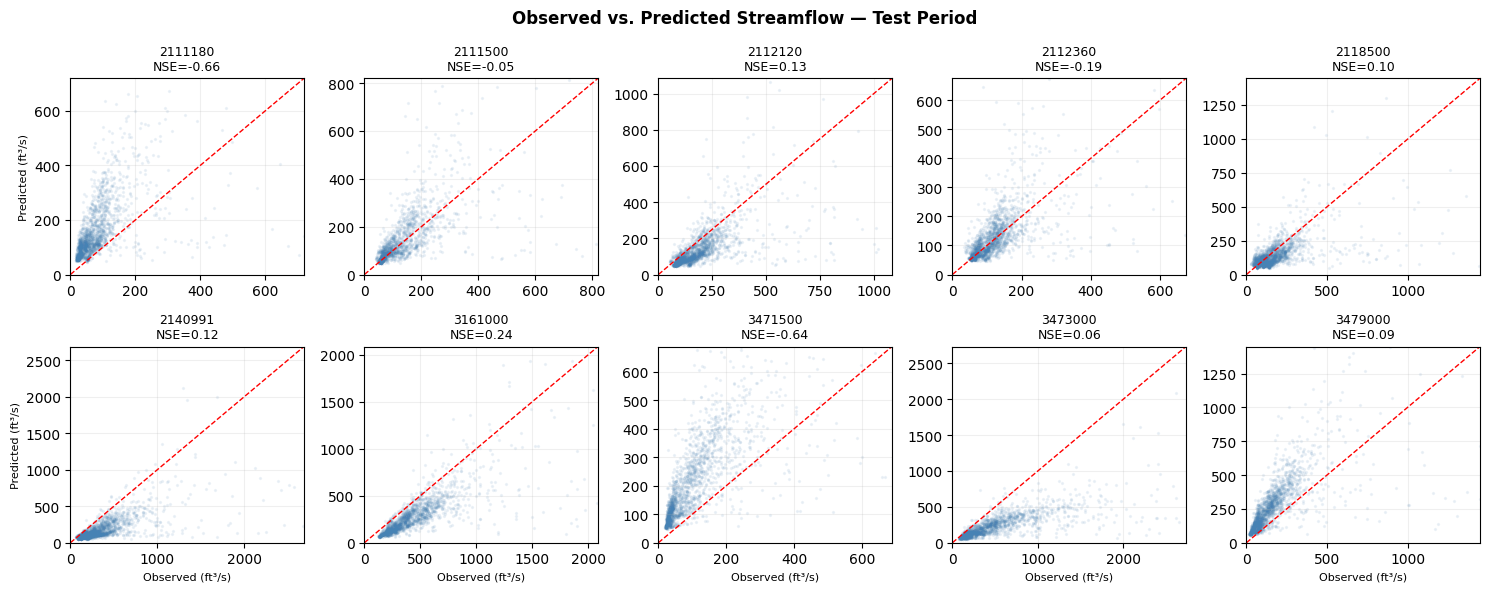

In [17]:
# Observed vs. predicted scatter — one panel per basin

plot_scatter_basins(
    obs_cfs_test=obs_cfs_test,
    pred_cfs_test=pred_cfs_test,
    gage_ids=loader.gage_ids,
    nse_by_basin=nse_baseline,
)



---
## 6. Hyperparameter Tuning, Overfitting, and Underfitting

Hyperparameters are settings you choose **before** training — the model never learns them.
Adjusting them to find the sweet spot is called **hyperparameter tuning**.

| Hyperparameter | What it controls |
|---|---|
| `hidden_size` | Model capacity |
| `dropout` | Regularization strength |
| `n_layers` | Model depth |
| `n_epochs` | Training duration |

---

### What happens if you tune them incorrectly?

| | **Underfitting** | **Overfitting** |
|---|---|---|
| **Symptoms** | High loss on both train and val | Low train loss, high val/test loss |
| **Root cause** | Model too simple or training too short | Model too complex, too little data, no regularization |
| **Fix** | Increase capacity, train longer | Add dropout, reduce size, more data, early stopping |

The goal is to find the *sweet spot* where both train and val loss are low and similar.

---

### Experiment: seeing the extremes

We deliberately push the hyperparameters to the extremes to see what failure looks like,
then confirm our baseline sits in the sweet spot:

1. **Underfit** — `hidden_size=4`, only 3 epochs
2. **Baseline** — `hidden_size=64`, 30 epochs, dropout=0.4 ✓ *this is our tuned model*
3. **Overfit** — `hidden_size=256`, 2 layers, no dropout, trained on just **1 year** of data


In [18]:
# Experiment A: Underfitting
# Too little model capacity + too little training time.

print("=== Underfitting (hidden=4, 3 epochs) ===")
model_under = LstmModel(n_features=N_FEATURES, hidden_size=4, n_layers=1, dropout=0.0).to(device)
print(f"  Parameters: {count_params(model_under):,}")

tl_under, vl_under = load_or_train(
    model=model_under,
    train_loader=train_loader,
    val_loader=val_loader,
    n_epochs=3,
    lr=1e-3,
    verbose=False,
    weights_path=WEIGHTS_DIR / "underfit.pt",
    train_from_scratch=TRAIN_FROM_SCRATCH,
    save_weights=SAVE_WEIGHTS,
)

pred_under = denormalize_target(predict_full_timeseries(model_under, x_test_norm, SEQ_LEN))
nse_under = np.nanmean([
    nse_score(pred_under[:, i], obs_cfs_test[:, i])
    for i in range(loader.n_basins)
])
print(f"  Mean NSE (test): {nse_under:.3f}")

=== Underfitting (hidden=4, 3 epochs) ===
  Parameters: 193
Loaded weights from underfit.pt  (best val loss: 1.0318)
  Mean NSE (test): -0.120

=== Overfitting (hidden=256, 2 layers, 1yr data, no dropout) ===
  Parameters: 1,054,721
Loaded weights from overfit.pt  (best val loss: 0.5281)
  Mean NSE (test): -0.262

=== Summary ===
  Underfitting: -0.120
  Baseline:     -0.080
  Overfitting:  -0.262
CPU times: user 2min 43s, sys: 2min 28s, total: 5min 11s
Wall time: 3min 4s


**What to look for:** both train and val loss are high and flat — the model has too little
capacity to learn anything useful. The hydrograph will show nearly constant predictions.

Now let's push to the opposite extreme.

In [ ]:
# Experiment B: Overfitting
# High model capacity + very small training dataset + no regularization.

print("=== Overfitting (hidden=256, 2 layers, 1yr data, no dropout) ===")
tiny_loader = make_overfit_loader(
    loader=loader,
    x_mean=x_mean,
    x_std=x_std,
    normalize_target=normalize_target,
    seq_len=SEQ_LEN,
    fallback_loader=train_loader,
)

model_over = LstmModel(n_features=N_FEATURES, hidden_size=256, n_layers=2, dropout=0.0).to(device)
print(f"  Parameters: {count_params(model_over):,}")

tl_over, vl_over = load_or_train(
    model=model_over,
    train_loader=tiny_loader,
    val_loader=val_loader,
    n_epochs=40,
    lr=1e-3,
    verbose=False,
    weights_path=WEIGHTS_DIR / "overfit.pt",
    train_from_scratch=TRAIN_FROM_SCRATCH,
    save_weights=SAVE_WEIGHTS,
)

pred_over = denormalize_target(predict_full_timeseries(model_over, x_test_norm, SEQ_LEN))
nse_over = np.nanmean([
    nse_score(pred_over[:, i], obs_cfs_test[:, i])
    for i in range(loader.n_basins)
])
print(f"  Mean NSE (test): {nse_over:.3f}")

nse_base_mean = np.nanmean(list(nse_baseline.values()))
print("\n=== Summary ===")
print(f"  Underfitting: {nse_under:.3f}")
print(f"  Baseline:     {nse_base_mean:.3f}")
print(f"  Overfitting:  {nse_over:.3f}")

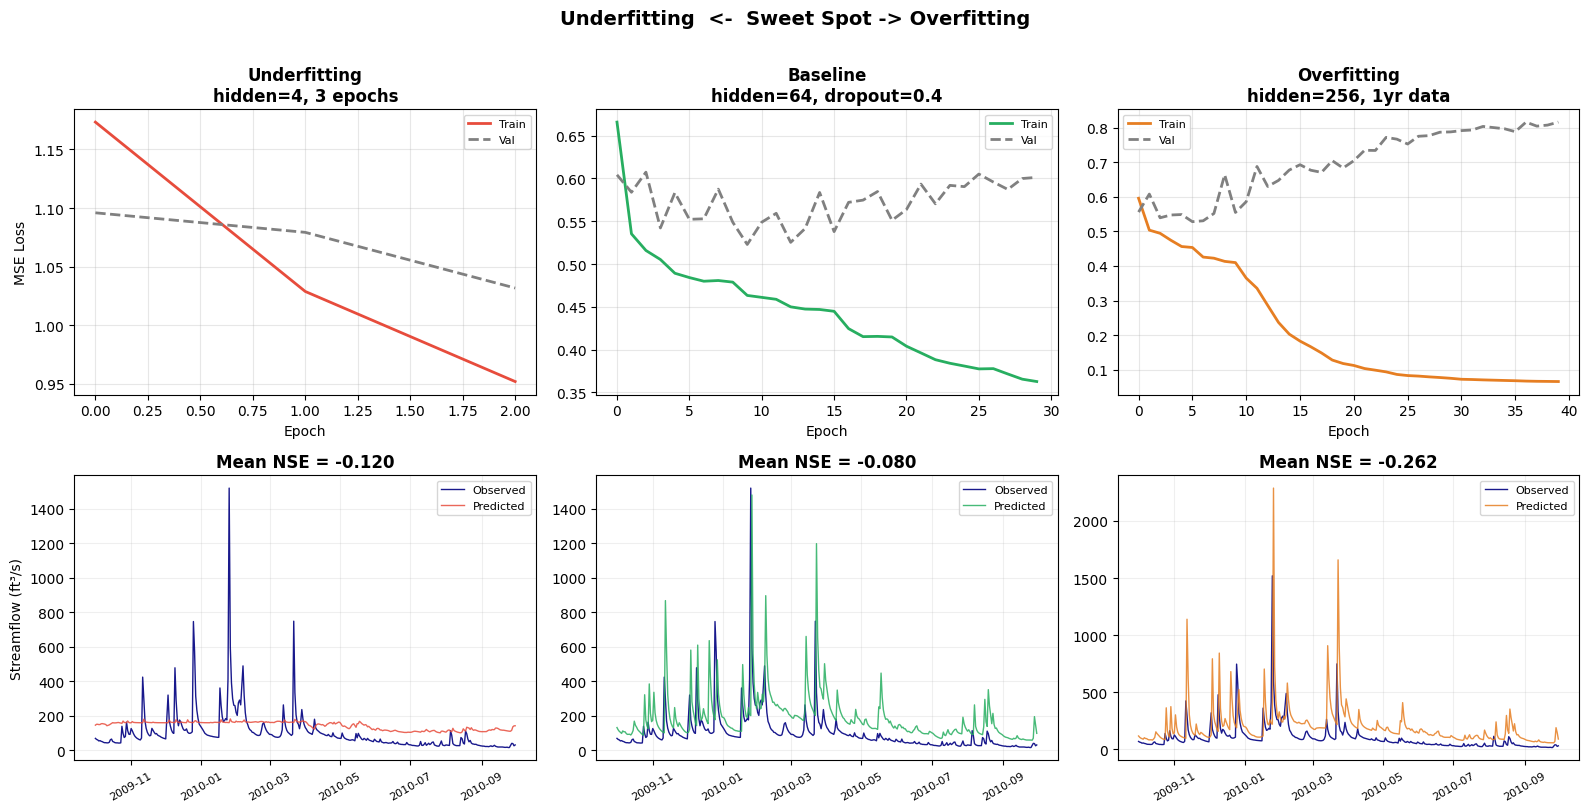

In [19]:
configs = [
    ("Underfitting\nhidden=4, 3 epochs", tl_under, vl_under, pred_under, nse_under, "#e74c3c"),
    ("Baseline\nhidden=64, dropout=0.4", train_losses, val_losses, pred_cfs_test, nse_base_mean, "#27ae60"),
    ("Overfitting\nhidden=256, 1yr data", tl_over, vl_over, pred_over, nse_over, "#e67e22"),
]

plot_bias_variance(
    dates_test=dates_test,
    obs_cfs_test=obs_cfs_test,
    configs=configs,
    basin_idx=0,
    n_plot=365,
    seq_len=SEQ_LEN,
    save_path="bias_variance_demo.png",
)


---
## 7. Feature Engineering: Changing the Input Representation

So far, we changed **model capacity** to demonstrate underfitting and overfitting.  
Now we keep the LSTM architecture mostly the same and change the **input representation**.

This is feature engineering: giving the model more useful information without changing the target.  
For streamflow prediction, useful engineered features include:

- recent accumulated precipitation, such as 7-day and 30-day precipitation sums
- seasonal timing, represented with sine/cosine day-of-year features

The teaching question is:

> If the model receives a better representation of hydrologic memory and seasonality, does performance change?

> **Think first** — before running the next cell, what precipitation accumulation windows would you choose?
> What does a 7-day sum capture that a 30-day sum doesn't? What about a 90-day sum?

In [20]:
# YOUR TURN — try different accumulation windows (e.g., (3, 14) or (7, 30, 90))
# and re-run this section to see whether the feature set changes NSE.
PRECIP_WINDOWS = (7, 30)

(
    x_train_fe_norm,
    x_val_fe_norm,
    x_test_fe_norm,
    feature_names_fe,
    x_fe_mean,
    x_fe_std,
) = make_feature_engineered_inputs(
    loader=loader,
    train_mask=train_mask,
    val_mask=val_mask,
    test_mask=test_mask,
    forcing_names=FORCING_NAMES,
    precip_windows=PRECIP_WINDOWS,
    include_seasonal_encoding=True,
)

print(f"Original number of features: {N_FEATURES}")
print(f"Feature-engineered number of features: {len(feature_names_fe)}")
print("\nFeature-engineered inputs:")
for name in feature_names_fe:
    print(f"  - {name}")

Original number of features: 6
Feature-engineered number of features: 10

Feature-engineered inputs:
  - prcp
  - tmean
  - pet
  - dayl
  - srad
  - vp
  - prcp_7day_sum
  - prcp_30day_sum
  - doy_sin
  - doy_cos


### Build datasets with the engineered features

Only the input features change here.  
The target, sequence length, train/validation/test split, and LSTM architecture style stay the same.


In [21]:
train_ds_fe = StreamflowDataset(x_train_fe_norm, y_train_norm, seq_len=SEQ_LEN, stride=STRIDE)
val_ds_fe = StreamflowDataset(x_val_fe_norm, y_val_norm, seq_len=SEQ_LEN, stride=STRIDE)

train_loader_fe = DataLoader(train_ds_fe, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader_fe = DataLoader(val_ds_fe, batch_size=BATCH_SIZE, shuffle=False)

print(f"Training samples: {len(train_ds_fe):,}")
print(f"Validation samples: {len(val_ds_fe):,}")
print(f"Sample shape with engineered features: {train_ds_fe[0][0].shape}")


Training samples: 9,400
Validation samples: 4,180
Sample shape with engineered features: torch.Size([365, 10])


### Train the same LSTM with the richer input representation

The main change is `n_features=len(feature_names_fe)`.  
This lets the same model receive the original forcings plus engineered hydrologic-memory and seasonal features.


In [22]:
model_fe = LstmModel(
    n_features=len(feature_names_fe),
    hidden_size=64,
    n_layers=1,
    dropout=0.4,
).to(device)

print(f"Feature-engineered model — {count_params(model_fe):,} trainable parameters")

train_losses_fe, val_losses_fe = load_or_train(
    model=model_fe,
    train_loader=train_loader_fe,
    val_loader=val_loader_fe,
    n_epochs=30,
    weights_path=WEIGHTS_DIR / "feature_engineered.pt",
    train_from_scratch=TRAIN_FROM_SCRATCH,
    save_weights=SAVE_WEIGHTS,
)

print(f"\nBest val loss: {min(val_losses_fe):.4f}")


Feature-engineered model — 34,049 trainable parameters
Loaded weights from feature_engineered.pt  (best val loss: 0.4928)

Best val loss: 0.4928


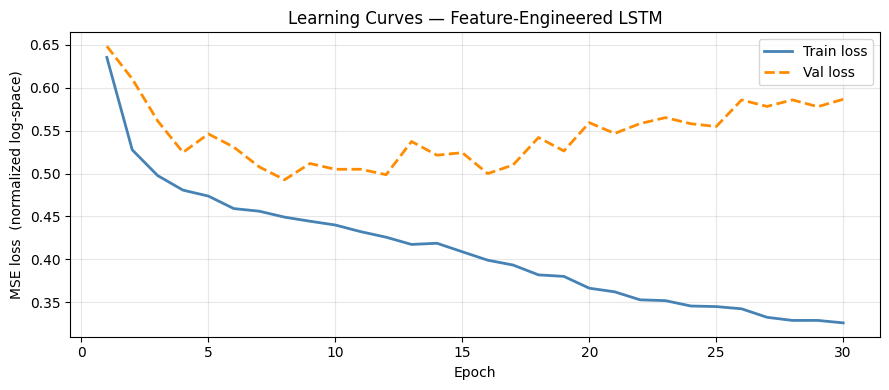

In [23]:
plot_learning_curves(
    train_losses_fe,
    val_losses_fe,
    title="Learning Curves — Feature-Engineered LSTM",
)


### Compare baseline vs. feature-engineered performance

This comparison asks whether changing the input representation helped the model generalize on the held-out test period.


In [24]:
pred_cfs_test_fe, nse_feature_engineered = evaluate_streamflow_model(
    model=model_fe,
    x_test_norm=x_test_fe_norm,
    obs_cfs_test=obs_cfs_test,
    denormalize_target=denormalize_target,
    seq_len=SEQ_LEN,
    gage_ids=loader.gage_ids,
)

nse_fe_mean = np.nanmean(list(nse_feature_engineered.values()))
nse_fe_median = np.nanmedian(list(nse_feature_engineered.values()))

print("NSE comparison — test period:")
print(f"  Baseline mean NSE:            {nse_base_mean:.3f}")
print(f"  Feature-engineered mean NSE:  {nse_fe_mean:.3f}")
print(f"  Change in mean NSE:           {nse_fe_mean - nse_base_mean:+.3f}")
print()
print(f"  Baseline median NSE:          {np.nanmedian(list(nse_baseline.values())):.3f}")
print(f"  Feature-engineered median NSE:{nse_fe_median:.3f}")


NSE comparison — test period:
  Baseline mean NSE:            -0.080
  Feature-engineered mean NSE:  -0.095
  Change in mean NSE:           -0.015

  Baseline median NSE:          0.075
  Feature-engineered median NSE:0.041


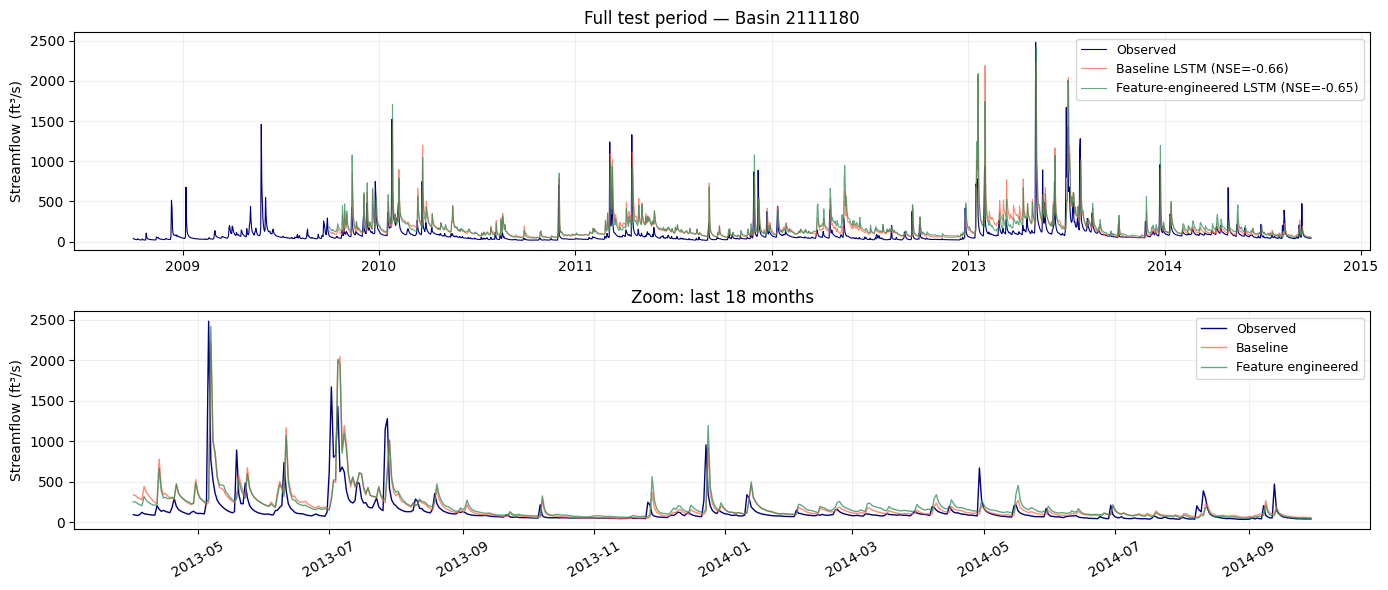

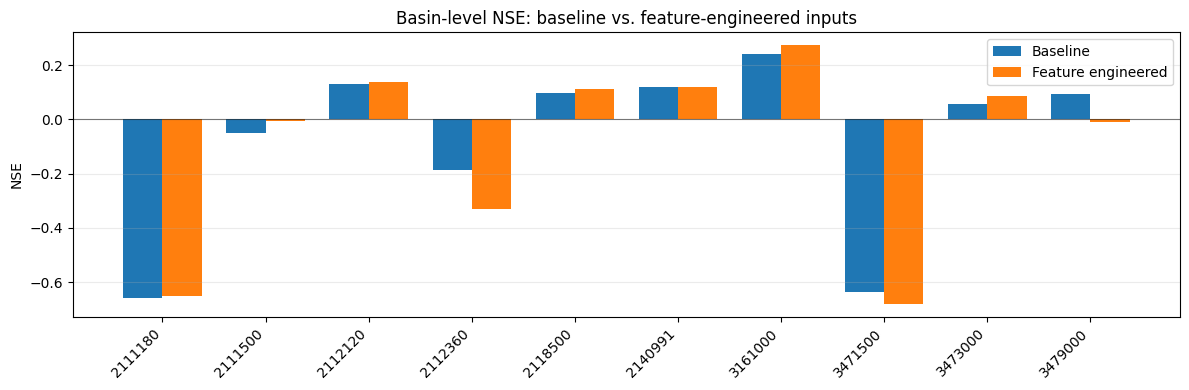

In [25]:
plot_feature_engineering_comparison(
    dates_test=dates_test,
    obs_cfs_test=obs_cfs_test,
    pred_baseline=pred_cfs_test,
    pred_feature_engineered=pred_cfs_test_fe,
    gage_ids=loader.gage_ids,
    nse_baseline=nse_baseline,
    nse_feature_engineered=nse_feature_engineered,
    basin_idx=0,
)

plot_nse_comparison(nse_baseline, nse_feature_engineered)


**Key takeaway:** feature engineering does not mean making the model more complex.  
Here, we kept the LSTM structure mostly fixed and changed what information the model receives.  
That is a core ML workflow idea: improve the data representation before jumping to more advanced architectures.



---
## Summary

You've built a complete, working ML pipeline for streamflow prediction and used it to understand how model design, diagnostics, and feature representation affect performance.

| Step | Accomplished |
|------|-------------|
| **Data** | Loaded 10-basin CAMELS data (12,418 days × 6 forcings × 10 basins) |
| **Preprocessing** | Temporal split, z-score normalization, log-transform, and sliding-window sequence creation |
| **Model** | Built an `LstmModel` with `nn.Module` using an encoder → LSTM → decoder structure |
| **Training** | Trained the model using Adam optimizer, masked MSE loss, gradient clipping, and a learning-rate scheduler |
| **Evaluation** | Evaluated model performance using NSE, hydrograph plots, and observed-vs-predicted scatter diagnostics |
| **Tuning & Diagnostics** | Tuned hyperparameters by observing failure modes at the extremes; demonstrated underfitting, a well-tuned baseline, and overfitting |
| **Feature Engineering** | Added engineered temporal and seasonal features, retrained the same LSTM structure, and compared performance against the baseline model |
---
### Things to try
1. **`hidden_size`** — try 16, 128. How does NSE vs. parameter count trade off?
2. **`dropout`** — remove it (`0.0`). Does the val curve diverge from train?
3. **`SEQ_LEN`** — try `30` (1 month) vs `730` (2 years). Does a longer window help?
4. **`STRIDE`** — reduce to `1` for the full dataset. Does more data improve NSE?

---
**Continue to `02_model_augmentation.ipynb`**: diagnose what the model gets wrong, then augment the architecture to improve it.
